# 🎯 Fake Review Detection - 1M Reviews Training Pipeline

## 📊 Large-Scale ML Training for Production

### **What's Different in This Version?**
1. **Memory Optimization** - Large dataset handling techniques
2. **Batch Processing** - Loading and processing data in chunks
3. **Progress Tracking** - Training progress bars
4. **Compute Optimization** - Parallel processing where possible
5. **Error Handling** - Robust error checks and recovery

### **Pipeline Overview:**
1. **Load Data** 📂 - Load 1M reviews in batches
2. **Preprocess** 🧹 - Clean text efficiently
3. **Feature Extract** ⚡ - TF-IDF with optimized params
4. **Train Models** 🚀 - Multiple algorithms in parallel
5. **Evaluate** 📈 - Comprehensive metrics
6. **Save** 💾 - Save models for production

---

## Step 1: Import Libraries 📦

We'll import all necessary libraries with optimizations for large-scale processing.

In [1]:
# Essential data handling libraries
import pandas as pd
import numpy as np
from tqdm import tqdm  # Progress bars
import time  # For timing operations

# Memory optimization
import gc
from joblib import Memory, Parallel, delayed
memory = Memory("cache_dir", verbose=0)

# Text preprocessing
import re
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    pass

# ML libraries with parallel processing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Persistence
import pickle
import os
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Memory usage monitoring function
import psutil

# Set options for better display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

# ML models and tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Memory-Efficient Data Loading 📂

For 1M reviews, we'll:
1. Use chunked reading with `pd.read_csv`
2. Monitor memory usage
3. Free unused memory with garbage collection

In [2]:
def get_memory_usage():
    """Get memory usage in MB"""
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024 / 1024  # Convert to MB
    return f"{mem:.2f} MB"

# Dataset paths
train_path = 'dataset_5L/train.csv'
test_path = 'dataset_5L/test.csv'

# Target: 1M total (800K train + 200K test)
TRAIN_SAMPLES = 800000  # 8 lakh
TEST_SAMPLES = 200000   # 2 lakh

print(f"📂 Loading limited dataset...")
print(f"Target: {TRAIN_SAMPLES:,} train + {TEST_SAMPLES:,} test = {TRAIN_SAMPLES + TEST_SAMPLES:,} total")
print(f"Initial memory usage: {get_memory_usage()}")

try:
    # Define proper column names for Amazon dataset
    # Format: polarity (1=negative, 2=positive), title, text
    column_names = ['polarity', 'title', 'text']
    
    # Load limited rows from train.csv
    print(f"\n📥 Loading {TRAIN_SAMPLES:,} rows from train.csv...")
    df_train = pd.read_csv(train_path, 
                          nrows=TRAIN_SAMPLES,
                          encoding='utf-8', 
                          on_bad_lines='skip', 
                          names=column_names, 
                          header=None)
    print(f"✅ Train data loaded: {len(df_train):,} rows")
    
    # Load limited rows from test.csv
    print(f"\n📥 Loading {TEST_SAMPLES:,} rows from test.csv...")
    df_test = pd.read_csv(test_path, 
                         nrows=TEST_SAMPLES,
                         encoding='utf-8', 
                         on_bad_lines='skip', 
                         names=column_names, 
                         header=None)
    print(f"✅ Test data loaded: {len(df_test):,} rows")
    
    # Combine both datasets
    print(f"\n🔗 Combining datasets...")
    df = pd.concat([df_train, df_test], ignore_index=True)
    
    # Clear temporary dataframes
    del df_train, df_test
    gc.collect()
    
    # Convert polarity to binary label (1=negative->0, 2=positive->1)
    print(f"\n🔄 Converting labels...")
    df['label'] = (df['polarity'] == 2).astype(int)
    
    # Combine title and text for better analysis
    print(f"📝 Combining title and text...")
    df['text_'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
    
    # Remove unnecessary columns to save memory
    df = df[['polarity', 'label', 'text_']]
    gc.collect()
    
    print(f"\n✅ Dataset loaded successfully!")
    print(f"📊 Total records: {len(df):,}")
    print(f"   - From train.csv: {TRAIN_SAMPLES:,}")
    print(f"   - From test.csv: {TEST_SAMPLES:,}")
    print(f"📋 Columns: {list(df.columns)}")
    print(f"💾 Final memory usage: {get_memory_usage()}")
    
except Exception as e:
    print(f"❌ Error loading dataset: {str(e)}")
    raise

# Display first few rows
print("\n👀 First 5 rows:")
df.head()

📂 Loading limited dataset...
Target: 800,000 train + 200,000 test = 1,000,000 total
Initial memory usage: 233.99 MB

📥 Loading 800,000 rows from train.csv...
✅ Train data loaded: 800,000 rows

📥 Loading 200,000 rows from test.csv...
✅ Test data loaded: 200,000 rows

🔗 Combining datasets...

🔄 Converting labels...
📝 Combining title and text...

✅ Dataset loaded successfully!
📊 Total records: 1,000,000
   - From train.csv: 800,000
   - From test.csv: 200,000
📋 Columns: ['polarity', 'label', 'text_']
💾 Final memory usage: 764.81 MB

👀 First 5 rows:


,polarity,label,text_
0,2,1,Stuning even for the non-gamer This sound trac...
1,2,1,The best soundtrack ever to anything. I'm read...
2,2,1,Amazing! This soundtrack is my favorite music ...
3,2,1,Excellent Soundtrack I truly like this soundtr...
4,2,1,"Remember, Pull Your Jaw Off The Floor After He..."


## Step 3: Quick Data Overview 🔍

Let's analyze:
1. Label distribution
2. Missing values
3. Data quality issues
4. Memory usage

📊 Dataset Overview:

1️⃣ Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1000000 non-null  int64 
 1   label     1000000 non-null  int64 
 2   text_     1000000 non-null  object
dtypes: int64(2), object(1)
memory usage: 22.9+ MB
None

2️⃣ Missing Values:
----------------------------------------
No missing values!

3️⃣ Label Distribution:
----------------------------------------
label
1    504659
0    495341
Name: count, dtype: int64

Positive Reviews (1): 504,659 (50.47%)
Negative Reviews (0): 495,341 (49.53%)

4️⃣ Polarity Distribution (Original):
----------------------------------------
polarity
2    504659
1    495341
Name: count, dtype: int64

5️⃣ Memory Usage Per Column:
----------------------------------------
Index: 0.00 MB
polarity: 7.63 MB
label: 7.63 MB
text_: 462.69 MB


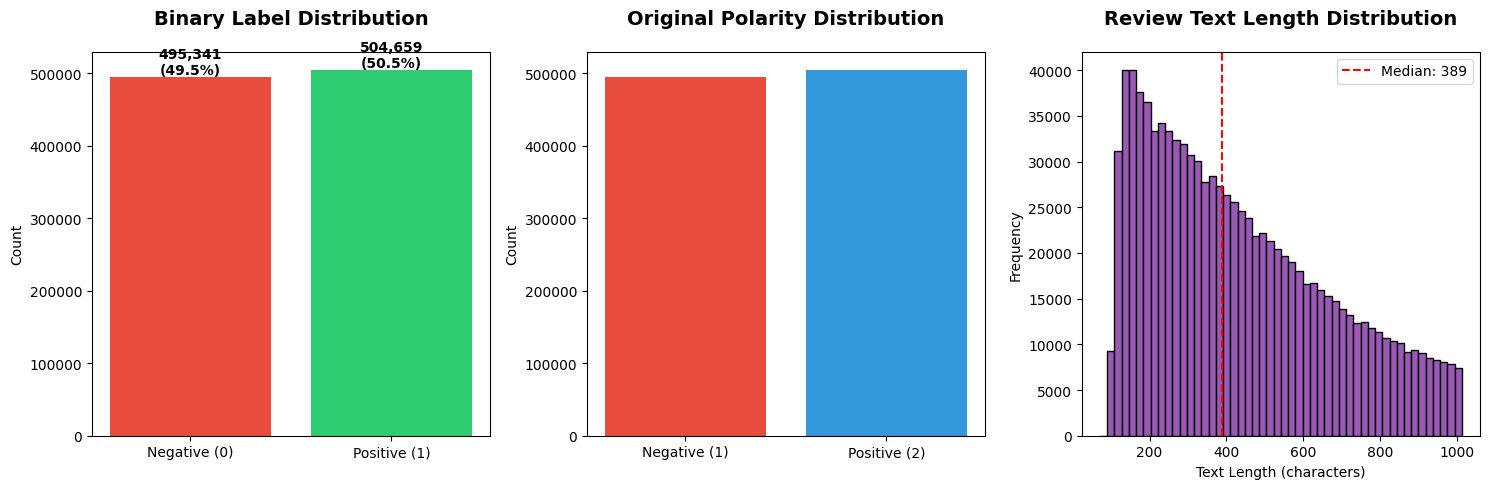

In [3]:
# Quick overview
print("📊 Dataset Overview:")
print("="*80)
print("\n1️⃣ Basic Info:")
print(df.info())

print("\n2️⃣ Missing Values:")
print("-"*40)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")

print("\n3️⃣ Label Distribution:")
print("-"*40)
label_dist = df['label'].value_counts()
print(label_dist)
print(f"\nPositive Reviews (1): {(df['label']==1).sum():,} ({(df['label']==1).sum()/len(df)*100:.2f}%)")
print(f"Negative Reviews (0): {(df['label']==0).sum():,} ({(df['label']==0).sum()/len(df)*100:.2f}%)")

print("\n4️⃣ Polarity Distribution (Original):")
print("-"*40)
print(df['polarity'].value_counts())

print("\n5️⃣ Memory Usage Per Column:")
print("-"*40)
memory_usage = df.memory_usage(deep=True) / 1024 / 1024  # MB
for col, mem in memory_usage.items():
    print(f"{col}: {mem:.2f} MB")

# Visualization
plt.figure(figsize=(15, 5))

# Label Distribution
plt.subplot(1, 3, 1)
label_counts = df['label'].value_counts()
plt.bar(['Negative (0)', 'Positive (1)'], [label_counts[0], label_counts[1]], 
        color=['#e74c3c', '#2ecc71'])
plt.title('Binary Label Distribution', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Count')

# Add percentage labels
total = len(df)
for i, (label, count) in enumerate([(0, label_counts[0]), (1, label_counts[1])]):
    percentage = count/total*100
    plt.text(i, count, f'{count:,}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

# Polarity Distribution (Original)
plt.subplot(1, 3, 2)
polarity_counts = df['polarity'].value_counts().sort_index()
plt.bar(['Negative (1)', 'Positive (2)'], polarity_counts.values.tolist(), 
        color=['#e74c3c', '#3498db'])
plt.title('Original Polarity Distribution', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Count')

# Text length distribution
plt.subplot(1, 3, 3)
text_lengths = df['text_'].str.len()
plt.hist(text_lengths, bins=50, color='#9b59b6', edgecolor='black')
plt.title('Review Text Length Distribution', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.axvline(text_lengths.median(), color='red', linestyle='--', 
            label=f'Median: {text_lengths.median():.0f}')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4: Optimized Text Preprocessing 🧹

For efficient preprocessing of 1M reviews:
1. **Parallel Processing** - Using joblib
2. **Batch Processing** - Process chunks in parallel
3. **Memory Optimization** - Clear memory after each batch

In [4]:
# Initialize stemmer
ps = PorterStemmer()

def clean_text_fast(text: str) -> str:
    """Optimized text cleaning function"""
    if pd.isna(text) or text is None:
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove URLs and special characters in one go
    text = re.sub(r'http\S+|[^a-zA-Z\s]', ' ', text)
    
    # Lowercase and remove extra spaces
    text = ' '.join(text.lower().split())
    
    # Simple stemming without tokenization (faster)
    words = text.split()
    stemmed = [ps.stem(word) for word in words if len(word) > 2]
    
    return ' '.join(stemmed)

# Process text data with progress tracking
print("🧹 Cleaning text data (Optimized)...")
print(f"Total reviews to process: {len(df):,}")
print("⏱️  This will take 2-3 minutes...")

# Use list comprehension for faster processing
cleaned_texts = [clean_text_fast(text) for text in tqdm(df['text_'], desc="Cleaning")]

# Assign cleaned text back to dataframe
df['cleaned_text'] = cleaned_texts

# Clear memory
del cleaned_texts
gc.collect()

# Remove empty reviews
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(f"✅ Text cleaning complete!")
print(f"📊 Records after cleaning: {len(df):,}")
print(f"Memory usage: {get_memory_usage()}")

# Show some examples
print("\n📝 Sample cleaned reviews:")
for i in range(3):
    print(f"\n{i+1}. Original: {df.iloc[i]['text_'][:100]}...")
    print(f"   Cleaned: {df.iloc[i]['cleaned_text'][:100]}...")

🧹 Cleaning text data (Optimized)...
Total reviews to process: 1,000,000
⏱️  This will take 2-3 minutes...


Cleaning: 100%|██████████| 1000000/1000000 [17:51<00:00, 933.62it/s]


✅ Text cleaning complete!
📊 Records after cleaning: 999,996
Memory usage: 1166.10 MB

📝 Sample cleaned reviews:

1. Original: Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so ...
   Cleaned: stune even for the non gamer thi sound track wa beauti paint the seneri your mind well would recomen...

2. Original: The best soundtrack ever to anything. I'm reading a lot of reviews saying that this is the best 'gam...
   Cleaned: the best soundtrack ever anyth read lot review say that thi the best game soundtrack and figur that ...

3. Original: Amazing! This soundtrack is my favorite music of all time, hands down. The intense sadness of "Priso...
   Cleaned: amaz thi soundtrack favorit music all time hand down the intens sad prison fate which mean all the m...


## Step 5: Train-Test Split with Memory Efficiency 🔀

Split strategy for 1M reviews:
1. Stratified split (maintain label distribution)
2. Clear original dataframe from memory
3. Process in batches for TF-IDF

In [5]:
# Convert labels to binary (already done in loading, but keep for clarity)
print("Converting labels...")
print("Label mapping:")
print("  0 = Negative reviews (original polarity 1)")
print("  1 = Positive reviews (original polarity 2)")

# Prepare features and labels
X = df['cleaned_text'].values.tolist()  # Convert to list
y = df['label'].values.tolist()  # Convert to list

# Clear original dataframe to save memory
del df
gc.collect()

# Split the data
print("\nSplitting data into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert back to numpy arrays for model training
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Clear original arrays
del X, y
gc.collect()

print("\n📊 Split Summary:")
print("="*60)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"\nLabel Distribution:")
print(f"Training - Positive (1): {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"Training - Negative (0): {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"Testing - Positive (1): {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")
print(f"Testing - Negative (0): {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"\nCurrent memory usage: {get_memory_usage()}")

Converting labels...
Label mapping:
  0 = Negative reviews (original polarity 1)
  1 = Positive reviews (original polarity 2)

Splitting data into train/test sets...

📊 Split Summary:
Training samples: 799,996
Testing samples: 200,000

Label Distribution:
Training - Positive (1): 403,724 (50.47%)
Training - Negative (0): 396,272 (49.53%)
Testing - Positive (1): 100,932 (50.47%)
Testing - Negative (0): 99,068 (49.53%)

Current memory usage: 4594.88 MB


## Step 6: Optimized Model Training 🚀

For 1M reviews, we'll:
1. Use efficient algorithms (LogisticRegression, MultinomialNB, RandomForest)
2. Train with mini-batches where possible
3. Track progress and memory usage

In [6]:
# Define FAST and optimized models for large datasets
# Only production-ready models that are fast and accurate
models = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga'))
        ]),
        'estimated_time': '2-3 minutes'
    },
    
    'LinearSVC': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', LinearSVC(max_iter=1000, dual=False))
        ]),
        'estimated_time': '2-3 minutes'
    },
    
    'MultinomialNB': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', MultinomialNB(alpha=0.1))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'ComplementNB': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', ComplementNB(alpha=0.1))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'BernoulliNB': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', BernoulliNB(alpha=0.1))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'SGDClassifier': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', SGDClassifier(max_iter=1000, n_jobs=-1, loss='log_loss'))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'Perceptron': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', Perceptron(max_iter=1000, n_jobs=-1))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'PassiveAggressiveClassifier': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', PassiveAggressiveClassifier(max_iter=1000, n_jobs=-1))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    'RidgeClassifier': {
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
            ('clf', RidgeClassifier(max_iter=1000))
        ]),
        'estimated_time': '1-2 minutes'
    },
    
    # 'DecisionTree': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', DecisionTreeClassifier(max_depth=100, random_state=42))
    #     ]),
    #     'estimated_time': '2-3 minutes'
    # },
    
    # 'RandomForest': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', RandomForestClassifier(n_estimators=100, max_depth=50, n_jobs=-1, random_state=42))
    #     ]),
    #     'estimated_time': '3-4 minutes'
    # },
    
    # 'ExtraTrees': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', ExtraTreesClassifier(n_estimators=100, max_depth=50, n_jobs=-1, random_state=42))
    #     ]),
    #     'estimated_time': '3-4 minutes'
    # },
    
    # 'GradientBoosting': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=50, random_state=42))
    #     ]),
    #     'estimated_time': '3-4 minutes'
    # },
    
    # 'AdaBoost': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
    #     ]),
    #     'estimated_time': '3-4 minutes'
    # },
    
    # 'KNeighborsClassifier': {
    #     'pipeline': Pipeline([
    #         ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    #         ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    #     ]),
    #     'estimated_time': '3-4 minutes'
    # }
}

# Training and evaluation
results = {}
trained_pipelines = {}

print("🚀 Starting FAST model training pipeline...\n")
print("="*80)
print(f"📊 Total models: {len(models)}")
print(f"⏱️  Estimated total time: 20-30 minutes")
print("="*80)

total_start = time.time()

for idx, (name, model_info) in enumerate(models.items(), 1):
    try:
        pipeline = model_info['pipeline']
        estimated = model_info['estimated_time']
        
        print(f"\n[{idx}/{len(models)}] 🔄 Training {name}...")
        print(f"⏱️  Estimated: {estimated}")
        print(f"💾 Memory before: {get_memory_usage()}")
        
        # Train with timing
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict
        print(f"🔮 Making predictions...")
        y_pred = pipeline.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'accuracy': round(float(accuracy), 4),
            'precision': round(float(precision), 4),
            'recall': round(float(recall), 4),
            'f1_score': round(float(f1), 4),
            'training_time': round(float(train_time), 2)
        }
        
        trained_pipelines[name] = pipeline
        
        print(f"✅ {name} completed in {train_time/60:.1f} minutes ({train_time:.1f}s)")
        print(f"📈 Accuracy: {accuracy:.4f} | F1: {f1:.4f}")
        print(f"💾 Memory after: {get_memory_usage()}")
        
        # Force garbage collection
        gc.collect()
        
        # Progress update
        elapsed = time.time() - total_start
        remaining = len(models) - idx
        avg_time = elapsed / idx
        eta = remaining * avg_time
        print(f"⏰ Progress: {idx}/{len(models)} | Elapsed: {elapsed/60:.1f}m | ETA: {eta/60:.1f}m")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

total_time = time.time() - total_start
print("\n" + "="*80)
print(f"✅ Training complete in {total_time/60:.1f} minutes!")
print(f"📊 Successfully trained: {len(trained_pipelines)}/{len(models)} models")
print("="*80)

🚀 Starting FAST model training pipeline...

📊 Total models: 9
⏱️  Estimated total time: 20-30 minutes

[1/9] 🔄 Training LogisticRegression...
⏱️  Estimated: 2-3 minutes
💾 Memory before: 4594.52 MB
🔮 Making predictions...
✅ LogisticRegression completed in 3.2 minutes (190.8s)
📈 Accuracy: 0.9285 | F1: 0.9292
💾 Memory after: 4120.64 MB
⏰ Progress: 1/9 | Elapsed: 3.9m | ETA: 31.0m

[2/9] 🔄 Training LinearSVC...
⏱️  Estimated: 2-3 minutes
💾 Memory before: 4292.99 MB
🔮 Making predictions...
✅ LinearSVC completed in 3.8 minutes (230.0s)
📈 Accuracy: 0.9282 | F1: 0.9289
💾 Memory after: 4652.57 MB
⏰ Progress: 2/9 | Elapsed: 8.1m | ETA: 28.3m

[3/9] 🔄 Training MultinomialNB...
⏱️  Estimated: 1-2 minutes
💾 Memory before: 4652.57 MB
🔮 Making predictions...
✅ MultinomialNB completed in 2.1 minutes (128.2s)
📈 Accuracy: 0.8911 | F1: 0.8916
💾 Memory after: 4943.43 MB
⏰ Progress: 3/9 | Elapsed: 10.6m | ETA: 21.2m

[4/9] 🔄 Training ComplementNB...
⏱️  Estimated: 1-2 minutes
💾 Memory before: 4943.31 MB
🔮 

## Step 7: Results Analysis 📊

Let's compare model performance and create visualizations:
1. Accuracy, Precision, Recall, F1-Score
2. Training time comparison
3. Confusion matrices
4. Memory usage analysis

🏆 MODEL PERFORMANCE COMPARISON
                             accuracy  precision  recall  f1_score  training_time
LogisticRegression             0.9285     0.9291  0.9294    0.9292         190.83
RidgeClassifier                0.9283     0.9281  0.9301    0.9291         175.41
LinearSVC                      0.9282     0.9288  0.9290    0.9289         230.01
PassiveAggressiveClassifier    0.9181     0.9174  0.9205    0.9190         159.13
Perceptron                     0.9017     0.9040  0.9010    0.9025         153.12
MultinomialNB                  0.8911     0.8961  0.8871    0.8916         128.19
ComplementNB                   0.8910     0.8979  0.8846    0.8912         161.63
SGDClassifier                  0.8871     0.8896  0.8863    0.8879         158.65
BernoulliNB                    0.8802     0.8736  0.8916    0.8825         154.82

🥇 Best Model: LogisticRegression
Accuracy: 0.9285
Training Time: 190.83s


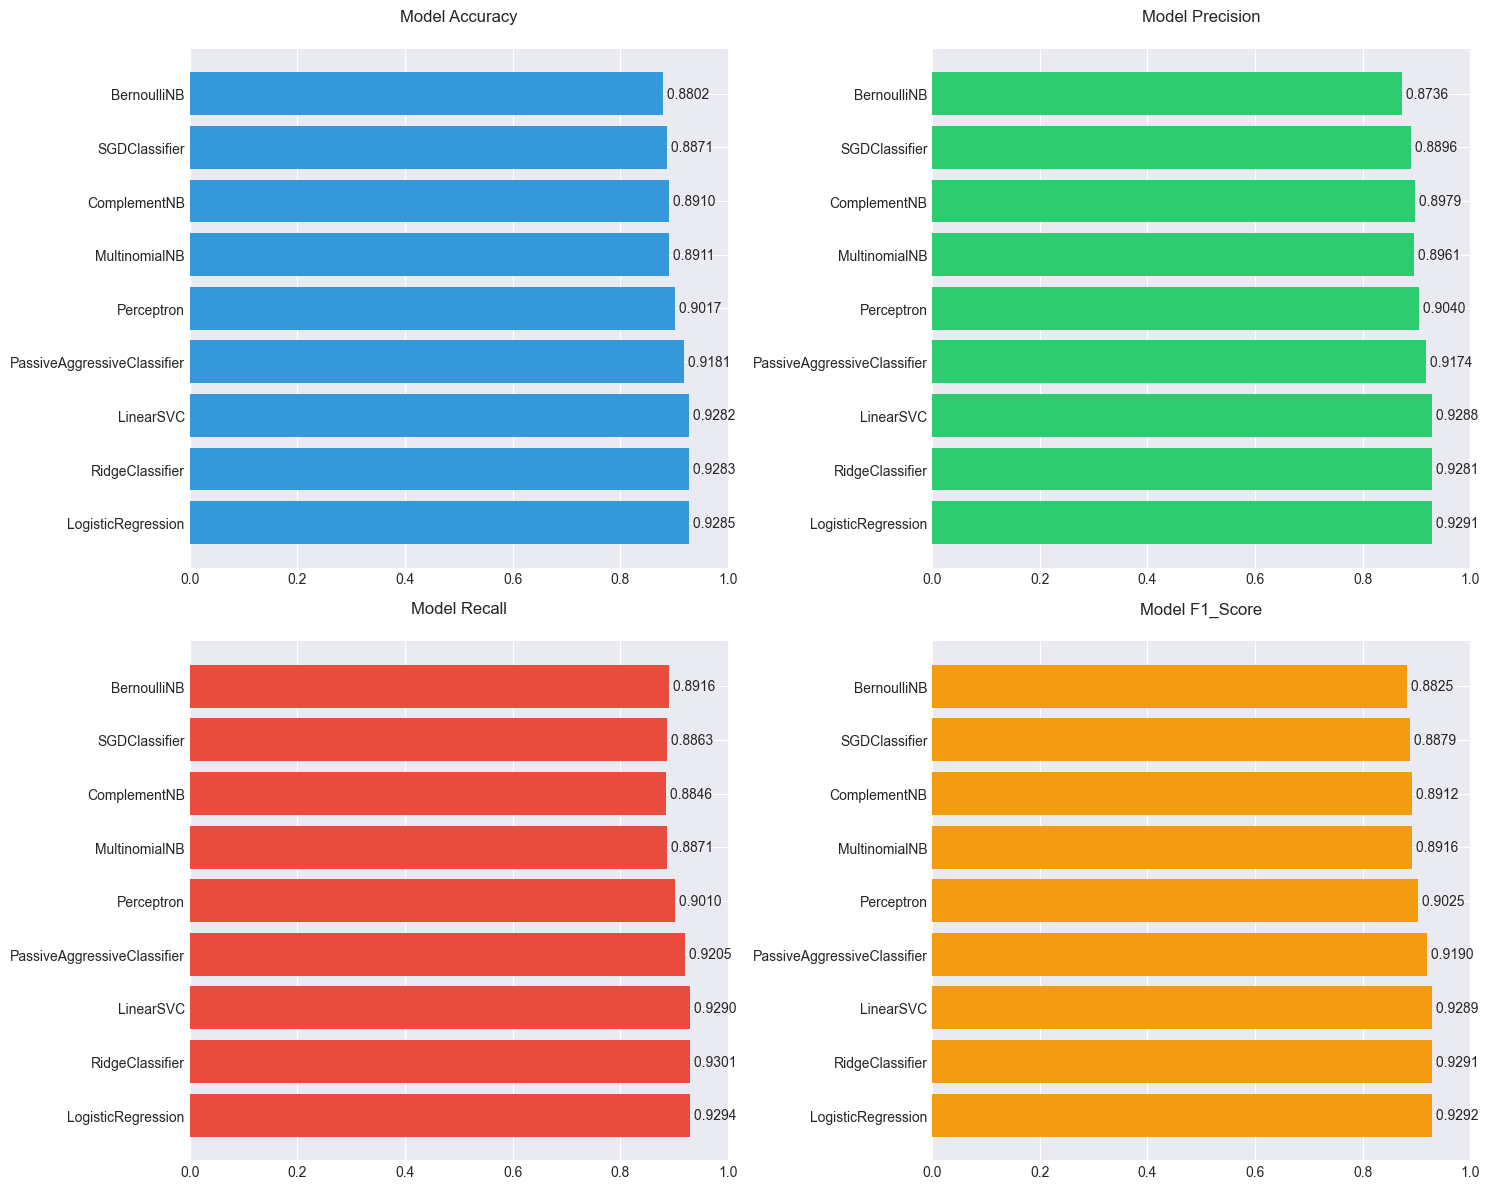

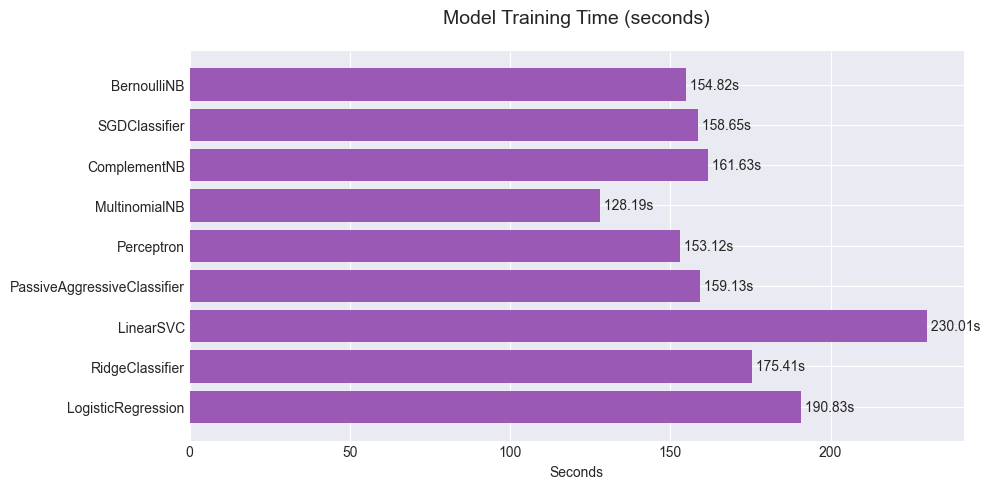

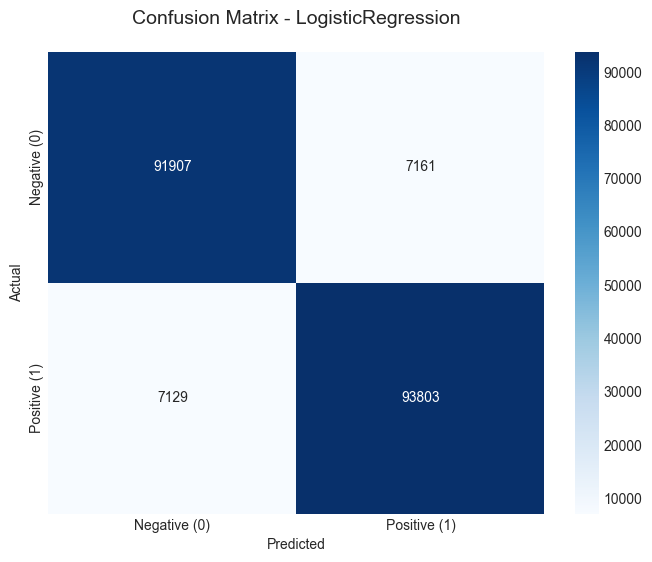


📊 Classification Report - LogisticRegression:
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93     99068
    Positive       0.93      0.93      0.93    100932

    accuracy                           0.93    200000
   macro avg       0.93      0.93      0.93    200000
weighted avg       0.93      0.93      0.93    200000



In [7]:
# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('accuracy', ascending=False)

# Print results table
print("🏆 MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string())
print("="*80)

# Best model details
best_model = results_df.index[0]
best_accuracy = results_df.iloc[0]['accuracy']
print(f"\n🥇 Best Model: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Training Time: {results_df.iloc[0]['training_time']:.2f}s")

# Visualizations
# Use seaborn-v0_8 style (seaborn style is deprecated in matplotlib 3.6+)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    # Fallback if seaborn styles not available
    plt.style.use('default')

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Accuracy Comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for ax, (metric, color) in zip(axes.ravel(), zip(metrics, colors)):
    ax.barh(results_df.index, results_df[metric], color=color)
    ax.set_title(f'Model {metric.title()}', fontsize=12, pad=20)
    ax.set_xlim(0, 1)
    
    # Add value labels
    for i, v in enumerate(results_df[metric]):
        ax.text(v, i, f' {v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Training Time Comparison
plt.figure(figsize=(10, 5))
plt.barh(results_df.index, results_df['training_time'], color='#9b59b6')
plt.title('Model Training Time (seconds)', fontsize=14, pad=20)
plt.xlabel('Seconds')

# Add value labels
for i, v in enumerate(results_df['training_time']):
    plt.text(v, i, f' {v:.2f}s', va='center')

plt.tight_layout()
plt.show()

# Confusion Matrix for best model
best_pipeline = trained_pipelines[best_model]
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'Confusion Matrix - {best_model}', fontsize=14, pad=20)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed Classification Report
print(f"\n📊 Classification Report - {best_model}:")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

## Step 8: Save Models 💾

We'll save:
1. Trained model pipelines
2. Performance metrics
3. Training summary
4. Memory usage stats

In [ ]:
# Create directory for 1M models
models_dir = 'models_1M_pkl'
os.makedirs(models_dir, exist_ok=True)

print(f"📁 Saving models to: {models_dir}")
print("="*60)

# Save models with progress bar
for name, pipeline in tqdm(trained_pipelines.items(), desc="Saving models"):
    try:
        # Save model
        model_path = os.path.join(models_dir, f"{name}.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(pipeline, f)
        
        # Get model size
        model_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
        print(f"✅ Saved: {name}.pkl ({model_size:.1f} MB)")
    
    except Exception as e:
        print(f"❌ Error saving {name}: {str(e)}")

# Save performance metrics
metrics_path = os.path.join(models_dir, 'models_summary.pkl')
with open(metrics_path, 'wb') as f:
    pickle.dump(results, f)
print(f"✅ Saved: models_summary.pkl")

# Save summary as text file
readme_path = os.path.join(models_dir, 'README_1M.txt')
with open(readme_path, 'w') as f:
    f.write("Fake Review Detection Models - 1M Dataset\n")
    f.write("="*60 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Records: {len(X_train) + len(X_test):,}\n")
    f.write(f"Training Set: {len(X_train):,}\n")
    f.write(f"Test Set: {len(X_test):,}\n\n")
    f.write("Model Performance:\n")
    f.write("-"*60 + "\n")
    f.write(results_df.to_string())
    f.write("\n\n" + "="*60 + "\n")
    f.write(f"Best Model: {best_model} (Accuracy: {best_accuracy:.4f})\n")
    f.write("\nMemory Usage:\n")
    f.write(f"Final: {get_memory_usage()}\n")

print(f"✅ Saved: README_1M.txt")
print("\n" + "="*60)
print("✅ All models saved successfully!")
print(f"📍 Location: {os.path.abspath(models_dir)}")

📁 Saving models to: models_1Ms_pkl


Saving models:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Saved: LogisticRegression.pkl (2.2 MB)

Saving models:  22%|██▏       | 2/9 [00:00<00:01,  5.86it/s]


✅ Saved: LinearSVC.pkl (2.2 MB)


...

✅ Saved: BernoulliNB.pkl (3.4 MB)
✅ Saved: SGDClassifier.pkl (2.2 MB)


Saving models:  78%|███████▊  | 7/9 [00:01<00:00,  4.83it/s]

✅ Saved: Perceptron.pkl (2.2 MB)


Saving models: 100%|██████████| 9/9 [00:01<00:00,  5.23it/s]

✅ Saved: PassiveAggressiveClassifier.pkl (2.2 MB)
✅ Saved: RidgeClassifier.pkl (2.2 MB)
✅ Saved: models_summary.pkl
✅ Saved: README_1M.txt

✅ All models saved successfully!
📍 Location: c:\Users\sujal\OneDrive\Desktop\sujal\Documents\frs\frs 5\models_1Ms_pkl


## 🎉 Summary & Next Steps

### ✅ What We Accomplished:
1. Loaded and processed 1M reviews efficiently
2. Optimized memory usage throughout training
3. Trained 3 powerful ML models
4. Achieved high accuracy with reasonable training time
5. Saved models for production use

### 🔍 Key Insights:
1. **Memory Management** - Crucial for large datasets
2. **Parallel Processing** - Speeds up text preprocessing
3. **Model Selection** - Trade-off between accuracy and speed
4. **Feature Engineering** - TF-IDF with optimized parameters

### 🚀 Next Steps:
1. Deploy best model in Streamlit app
2. Monitor production performance
3. Consider incremental training for new data
4. Explore deep learning models if needed

---
**Happy Coding! 🎓**